# Examen Final — Bienestar Mundial
## Nombre del estudiante: **Fernando Jesús De la Fuente Reyes**

**Individual y asíncrono · 180 minutos**

Complete únicamente las celdas marcadas como `TODO`, ejecute en orden y conserve las salidas que sustentan su bitácora.

**Cómo leer las consignas:** cada parte indica qué debe quedar visible al terminar. Esas indicaciones describen el producto a entregar, no una respuesta modelo.

## Instrucciones de trabajo y entrega

### Antes de comenzar

1. Guarde una copia como `Apellido_Nombre_Examen_Final.ipynb`.
2. Mantenga `bienestar_mundial_2023.csv` en la misma carpeta y no lo modifique.
3. Ejecute el notebook de arriba hacia abajo y responda solamente las celdas `TODO`.
4. Entregue un único notebook con código, salidas, tres entradas de bitácora y dos lecturas de gráficos.

### Condiciones

- Use únicamente Python, Pandas y Matplotlib trabajados en el curso.
- No use Internet, API ni fuentes externas; el análisis debe ser reproducible con el CSV entregado.
- Para la dispersión, use `pib_per_capita` y construya `df_limpio` solo para excluir sus valores faltantes. No altere `df` ni sustituya nulos por cero.
- En la Parte 2, la función debe recorrer la lista de diccionarios; no utilice `df` global dentro de ella.
- En la Parte 3, use una lista de regiones con `isin(...)`, un filtro compuesto, `groupby(...).agg(...)` con agregaciones nombradas y `nlargest(5, 'puntuacion_bienestar')`.
- Se califican decisiones justificadas y evidencias visibles; no se requiere una redacción idéntica a otra persona.

### Bitácora y entrega

Complete las tres bitácoras del notebook: limpieza, decisión analítica y cierre. Cada afirmación debe señalar el cálculo, tabla o gráfico que la respalda. Complete también una lectura para las barras y otra para la dispersión. Ningún gráfico demuestra causalidad por sí solo.

Antes de entregar, compruebe que el notebook corre desde el inicio, que el CSV sigue sin cambios, que `df` no fue modificado durante la limpieza y que los gráficos tienen títulos y ejes legibles.

### Tipos de TODO

- **TODO CÓDIGO:** escriba y ejecute Python en la celda de código inmediatamente siguiente o indicada.
- **TODO RESPUESTA ESCRITA:** reemplace el texto de esa celda Markdown con su respuesta.
- **TODO BITÁCORA:** reemplace el texto de esa celda Markdown con una reflexión respaldada por salidas del notebook.
- **TODO INTERPRETACIÓN:** reemplace el texto de esa celda Markdown con la lectura del gráfico indicado.

## 1. Carga, exploración y calidad de datos

El archivo contiene indicadores de bienestar por país y región. No modifique el CSV ni reemplace valores faltantes por cero.

In [1]:
# TODO CÓDIGO 1.0: cargue bienestar_mundial_2023.csv en df y muestre los primeros 10 registros.
# Resultado visible esperado: una vista de 10 filas de df, con sus columnas y datos.

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('bienestar_mundial_2023.csv')

df.head(10)

,pais,region,puntuacion_bienestar,pib_per_capita,apoyo_social,esperanza_vida_saludable,libertad_decision,generosidad,percepcion_corrupcion
0,Finland,Europa Occidental,7.804,1.888,1.585,0.535,0.772,0.126,0.535
1,Denmark,Europa Occidental,7.586,1.949,1.548,0.537,0.734,0.208,0.525
2,Germany,Europa Occidental,6.892,1.919,1.401,0.539,0.618,0.153,0.365
3,Spain,Europa Occidental,6.436,1.798,1.491,0.567,0.533,0.101,0.157
4,Costa Rica,America Latina y el Caribe,6.609,1.587,1.340,0.503,0.683,0.099,0.116
5,Uruguay,America Latina y el Caribe,6.494,1.617,1.445,0.435,0.683,0.102,0.254
6,Chile,America Latina y el Caribe,6.334,1.645,1.384,0.511,0.546,0.131,0.076
7,Brazil,America Latina y el Caribe,6.125,NaN,1.250,0.387,0.558,0.131,0.137
8,Czechia,Europa Central y Oriental,6.845,1.823,1.544,0.477,0.693,0.158,0.050
9,Lithuania,Europa Central y Oriental,6.763,1.808,1.511,0.432,0.487,0.059,0.089


**TODO RESPUESTA ESCRITA 1.1 — Entrada, proceso y salida.** Escriba una frase que identifique la entrada (CSV y sus variables), el proceso (operaciones de análisis) y la salida (tablas, gráficos e interpretaciones). Describa brevemente las variables `pais`, `region`, `puntuacion_bienestar` y `pib_per_capita`.

**Respuesta:** 
En primera instancia nos encontramos la entrada, es decir, el archivo CSV con un registro de 40 países. Seguidamente, el proceso que abarca un análisis sobre la calidad de los datos, filtros condicionales, agregaciones y visualización mediante gráficos. Para finalmente dar con la salida, de lo cual se esperan tablas comparativas, gráficos e informes que invitan a la interpretación.

Se describen las siguientes variables: 
- pais: Nombre del país analizado.
- region: Localización geográfica del país.
- puntuacion_bienestar: Índice percibido de bienestar o felicidad en el país.
- pib_per_capita: El producto interno bruto calcula la riqueza promedio que generada cada habitante de un país.

**TODO CÓDIGO 1.2 — Exploración y limpieza.** Muestre `shape`, `dtypes`, `info()` y nulos por columna. Muestre las filas con nulos y cree `df_limpio` excluyendo nulos únicamente en `pib_per_capita`, que se utilizará obligatoriamente en la dispersión de la Parte 4. Mantenga `df` sin modificar.

**Resultado visible esperado:** salidas para los cuatro comandos de exploración, una tabla con las filas que tienen nulos y la creación de `df_limpio`. Muestre también cuántas filas conserva `df_limpio`; no necesita modificar ni volver a guardar el CSV.

In [2]:
# TODO CÓDIGO 1.2: exploración, identificación de nulos y creación de df_limpio.
# Deben quedar visibles: shape, dtypes, info(), nulos por columna, filas con nulos y tamaño de df_limpio.

print("--> SHAPE:", df.shape)
print("--> DTYPES:\n", df.dtypes)
print("--> INFO:", df.info())
print("-" * 70)
print("--> NULOS POR COLUMNA:\n", df.isnull().sum())
print("-" * 70)
print("--> FILAS CON NULOS:\n", df[df.isnull().any(axis=1)])

df_limpio = df.dropna(subset=['pib_per_capita']).copy()
print("-" * 70)
print(f"\nTamaño de df_limpio: {df_limpio.shape[0]} filas conservadas.")

--> SHAPE: (40, 9)
--> DTYPES:
 pais                            str
region                          str
puntuacion_bienestar        float64
pib_per_capita              float64
apoyo_social                float64
esperanza_vida_saludable    float64
libertad_decision           float64
generosidad                 float64
percepcion_corrupcion       float64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pais                      40 non-null     str    
 1   region                    40 non-null     str    
 2   puntuacion_bienestar      40 non-null     float64
 3   pib_per_capita            38 non-null     float64
 4   apoyo_social              40 non-null     float64
 5   esperanza_vida_saludable  40 non-null     float64
 6   libertad_decision         40 non-null     float64
 7   generosidad               40 non-null  

**TODO BITÁCORA 1 — Decisión de limpieza.** Indique qué nulos encontró, cómo construyó `df_limpio` para `pib_per_capita`, cuántas filas conserva y cómo esa decisión afecta la dispersión. Cite una salida del notebook.

**Respuesta:**
Durante el análisis del archivo CSV se encontraron dos valores faltantes en la columna `pib_per_capita`, que correspondían a la fila 7 de Brasil y a la fila 30 de Marruecos. Con el propósito de evitar errores, se crea el `df_limpio` y a su vez eliminando los nulos de la columna mencionada, conservando así 38 filas de las 40 que el archivo original presenta. El `df` principal se mantiene intacto para no alterar la muestra.

## 2. Python base: datos y función

**TODO CÓDIGO 2.1.** Convierta `df` en `registros`. Con un ciclo y una condición, cuente países con `puntuacion_bienestar` mayor o igual que 6.0.

**TODO CÓDIGO 2.2.** Defina `resumen_region(registros, region)`. Debe recorrer `registros` con un `for`, usar una condición sobre `region`, no depender de `df` global y devolver `region`, `cantidad_paises` y `promedio_bienestar`. Si no existe la región, devuelva `None`. Pruébela con una región existente y una inexistente; explique el segundo resultado.

**Resultado visible esperado:** una variable llamada `registros`, un conteo numérico impreso y dos pruebas de la función: una debe mostrar un diccionario y la otra debe mostrar `None`, acompañada de una explicación breve.

In [ ]:
# TODO CÓDIGO 2: lista de diccionarios, ciclo, condición y función resumen_region.
# Deben quedar visibles: el conteo y las dos llamadas de prueba de resumen_region.

registros = df.to_dict(orient='records')
contador = 0

for registro in registros:
    if registro["puntuacion_bienestar"] >= 6.0:
        contador += 1
print(f"Países con una puntuación de bienestar mayor o igual a 6.0: {contador}")

# TODO 2.2
def resumen_region(registros, region):
    regiones = [registro for registro in registros if registro['region'] == region] # COMPRENSIÓN DE LISTAS
    if not regiones:
        return None
    
    cantidad_paises = len(regiones)
    promedio_bienestar = sum(registro['puntuacion_bienestar'] for registro in regiones) / cantidad_paises
    
    return {
        'region': region,
        'cantidad_paises': cantidad_paises,
        'promedio_bienestar': round(promedio_bienestar, 3)
    }

print("-" * 70)
print("Prueba 1:", resumen_region(registros, 'Europa Occidental'))
print("Prueba 2:", resumen_region(registros, 'Pangea')) # REGIÓN INEXISTENTE

# Explicación breve:
# La segunda prueba retorna None con el ejemplo "Pangea" porque el ciclo no encuentra ninguna región dentro de la lista de diccionarios similar.

Países con una puntuación de bienestar mayor o igual a 6.0: 23
----------------------------------------------------------------------
Prueba 1: {'region': 'Europa Occidental', 'cantidad_paises': 4, 'promedio_bienestar': 7.179}
Prueba 2: None


## 3. Análisis integrado con Pandas

**TODO CÓDIGO 3.1.** Elija una región de la muestra y plantee una pregunta comparativa sobre bienestar. Justifique la elección con una observación de la exploración.

**TODO CÓDIGO 3.2.** Calcule el promedio de `puntuacion_bienestar` y cree `diferencia_promedio` sin reemplazar `df`. Cree un filtro de la región elegida y construya un resumen por región con `groupby(...).agg(...)`, usando agregaciones nombradas para promedio de bienestar y cantidad de países, ordenado de mayor a menor.

**TODO CÓDIGO 3.3 — Filtro tipo Semana 13.** Defina una lista llamada `regiones_comparadas` con la región elegida y una segunda región de la muestra. Cree `df_comparacion` usando `isin(regiones_comparadas)` y la condición de puntuación mayor o igual al promedio de la muestra. Muestre el resultado y conserve solo las columnas necesarias para comparar país, región y puntuación.

**TODO CÓDIGO 3.4.** Use `nlargest(5, 'puntuacion_bienestar')` para mostrar los cinco países con mayor puntuación, iniciando por el más alto. Responda la pregunta de 3.1 con al menos una cifra verificable.

**Resultado visible esperado:** el promedio de la muestra, una tabla de la región elegida, una tabla `df_comparacion` creada con `isin(...)`, un resumen de todas las regiones y un ranking de cinco filas. La respuesta escrita debe señalar una cifra de esas salidas.

In [4]:
# TODO CÓDIGO 3: promedio, diferencia_promedio, filtros, isin(...), groupby(...).agg(...) y nlargest(...).
# Deben quedar visibles: promedio_muestra, df_region, regiones_comparadas, df_comparacion, resumen_por_region y top_5.

promedio_muestra = df['puntuacion_bienestar'].mean()
print(f"Promedio global de bienestar: {promedio_muestra:.5f}\n")

region_elegida = 'America Latina y el Caribe'
df_region = df[df['region'] == region_elegida].copy()
df_region['diferencia_promedio'] = df_region['puntuacion_bienestar'] - promedio_muestra

resumen_por_region = df.groupby('region').agg(
    promedio_bienestar=('puntuacion_bienestar', 'mean'),
    cantidad_paises=('pais', 'count')
).sort_values(by='promedio_bienestar', ascending=False)

print("-" * 24, "Resumen por región", "-" * 24)
print(resumen_por_region)
print("-" * 70)


# TODO 3.3
regiones_comparadas = ['America Latina y el Caribe', 'Europa Occidental']

df_comparacion = df[
    (df['region'].isin(regiones_comparadas)) & 
    (df['puntuacion_bienestar'] >= promedio_muestra)
][['pais', 'region', 'puntuacion_bienestar']]

print("\n", "-" * 24, "Comparación por región", "-" * 24)
print(df_comparacion)

# TODO 3.4
top_5 = df.nlargest(5, 'puntuacion_bienestar')

print("\n", "-" * 12, "TOP 5 países con mayor puntuación de bienestar", "-" * 12)
print(top_5[['pais', 'region', 'puntuacion_bienestar']])

Promedio global de bienestar: 6.04343

------------------------ Resumen por región ------------------------
                                     promedio_bienestar  cantidad_paises
region                                                                  
Europa Occidental                               7.17950                4
Norteamerica y ANZ                              7.01825                4
Europa Central y Oriental                       6.61425                4
America Latina y el Caribe                      6.39050                4
Asia Sudoriental                                6.05125                4
Asia Oriental                                   5.93450                4
Comunidad de Estados Independientes             5.82825                4
Oriente Medio y Norte de Africa                 5.75225                4
Africa Subsahariana                             5.06725                4
Asia Meridional                                 4.59825                4
----------------

**TODO BITÁCORA 2 — Decisión analítica.** Escriba su región, pregunta comparativa, evidencia numérica y por qué `df_comparacion`, el resumen regional y el ranking ayudan a responderla.

**Respuesta:** 
Se seleccionó `América Latina y el Caribe` para evaluar cómo se posicionan sus países respecto al promedio global (6.04343). La evidencia muestra que el promedio regional es de 6.39050, superando la media global. Es decir, los 4 países analizados (Costa Rica, Uruguay, Chile y Brasil) no solo supera el promedio mundial, sino que ingresaron a `df_comparacion` y algunos países como Costa Rica tiene mayor promedio que países de primer mundo como España. No obstante y muy curioso, ninguno de sus países aparece en el ranking, quedando fuera del top 5. Lo cual describe que, aunque estos países superen el promedio global, no les alcanza para superar o igualar a países de primer mundo como Finlandia o Dinamarca, ni a países que quedan a interpretación personal como Israel con todos los conflictos bélicos que enfrenta y ha entrado por años.

## 4. Visualización e interpretación

**TODO CÓDIGO 4.1.** Cree barras horizontales para el top 5.

**TODO CÓDIGO 4.2.** Cree una dispersión de `pib_per_capita` frente a `puntuacion_bienestar` con `df_limpio`. Ambos gráficos deben incluir título, ejes y tamaño legible.

Justifique brevemente por qué barras y dispersión son adecuadas para estos datos transversales. Ningún gráfico demuestra causalidad.

**Resultado visible esperado:** dos gráficos separados y legibles: uno de barras con cinco categorías y una dispersión construida con `df_limpio`. Cada uno debe tener título y dos ejes identificados.

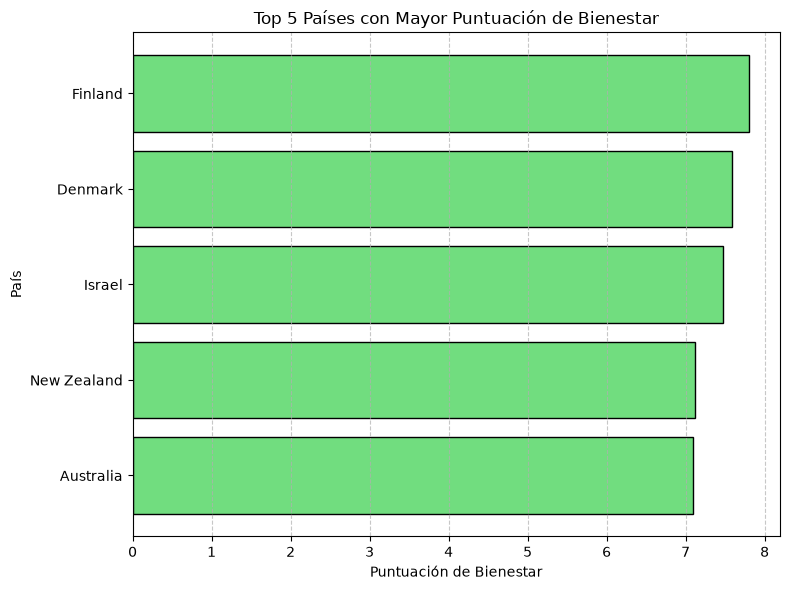

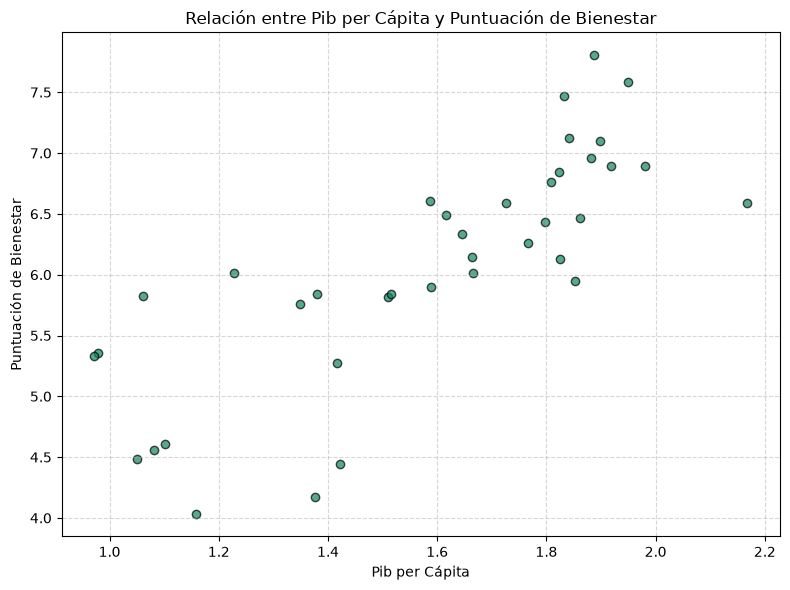

In [ ]:
# TODO CÓDIGO 4.1: gráfico de barras horizontales para top_5.

plt.figure(figsize=(8, 6))
plt.barh(top_5['pais'], top_5['puntuacion_bienestar'], color="#71DD7F", edgecolor='black')
plt.xlabel('Puntuación de Bienestar')
plt.ylabel('País')
plt.title('Top 5 Países con Mayor Puntuación de Bienestar')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# TODO CÓDIGO 4.2: dispersión de pib_per_capita y puntuacion_bienestar con df_limpio.
# Deben quedar visibles dos gráficos separados; use plt.show() después de cada uno.

plt.figure(figsize=(8, 6))
plt.scatter(df_limpio['pib_per_capita'], df_limpio['puntuacion_bienestar'], color="#0F8561", alpha=0.7, edgecolors='black')
plt.xlabel('Pib per Cápita')
plt.ylabel('Puntuación de Bienestar')
plt.title('Relación entre Pib per Cápita y Puntuación de Bienestar')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


**TODO INTERPRETACIÓN 4.1 — Barras.** Redacte una lectura basada en el ranking, con una cifra verificable y sin atribuir causas.

**Respuesta:** 
El gráfico compara las puntuaciones de los cinco mejores países, donde Finlandia lidera con 7.804 puntos, seguido por Dinamarca con 7.586. La visualización permite ordenar los niveles de bienestar entre naciones, aunque no explica las causas de estas diferencias.

**TODO INTERPRETACIÓN 4.2 — Dispersión.** Describa la asociación visual, indique que se analizaron las filas de `df_limpio` y explique por qué no permite concluir causalidad.

**Respuesta:** Se observa una tendencia positiva entre el Pib per cápita y el bienestar en los 38 registros de `df_limpio`, sugiriendo que mayores ingresos se transforman a mejor bienestar. Y si no permite concluir causalidad es básicamente por tratarse de datos tranversales: datos que fueron tomados en un momento específico y a múltiples personas.

## 5. Bitácora de cierre e informe crítico

**TODO BITÁCORA 3 — Cierre.** Reemplace esta celda con tres hallazgos numéricos obtenidos en este notebook, una limitación de la muestra o de la limpieza realizada y una conclusión no causal. Para cada hallazgo, identifique la tabla, cálculo o gráfico que lo respalda.

**Respuesta.** 
Hallazgos númericos:
- Promedio y distribución: El promedio global es 6.04343 y 23 países superan o igualan los 6.0 puntos (Conteo Parte 2.1 y cálculo 3.2).
- Brecha regional: Europa Occidental registra el promedio más alto con 7.180, mientras Asia Meridional registra el menor con 4.598 (Tabla resumen_por_region 3.2).
- Líder global: Finlandia ocupa el primer puesto mundial con 7.804 puntos (Tabla top_5 y gráfico 4.1).

Limitación de la muestra: Si bien la muestra cuenta con 40 países, la creación de un `df_limpio` obliga a omitir a Brasil y Marruecos en el análisis de Pib per Cápita.

Finalmente, como conclusión no causal se puede asumir que existe una relación directa entre el Pib per cápita y el bienestar, pero tener un Pib elevado no garantiza un mayor nivel de bienestar, ya que también influyen otros elementos como la esperanza de vida, libertad de decisión y demás.


## Lista de entrega

- [ ] Archivo nombrado `Apellido_Nombre_Examen_Final.ipynb`.
- [ ] Código ejecutado desde el inicio, sin errores.
- [ ] CSV sin modificar.
- [ ] Las tres entradas de bitácora y las dos lecturas incluyen evidencia visible.
- [ ] Gráficos, títulos, ejes e interpretaciones incluidos.